In [1]:
from quickdraw import QuickDrawDataGroup
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
with open('../../categories/sports.txt') as f:
    CATEGORIES = [c.strip() for c in f.read().split(',')]
print(CATEGORIES)

['baseball', 'baseball bat', 'basketball', 'bicycle', 'canoe', 'dumbbell', 'diving board', 'golf club', 'hockey puck', 'hockey stick', 'rollerskates', 'skateboard', 'soccer ball', 'tennis racquet', 'yoga']


In [3]:
SAMPLES = 500
IMG_SIZE = 16
images = []
labels = []
for cat in CATEGORIES:
    group = QuickDrawDataGroup(cat, max_drawings=SAMPLES)
    for drawing in group.drawings:
        img = np.array(drawing.image.convert('L').resize((IMG_SIZE, IMG_SIZE)))
        images.append(img)
        labels.append(cat)

loading baseball drawings
load complete
loading baseball bat drawings
load complete
loading basketball drawings
load complete
loading bicycle drawings
load complete
loading canoe drawings
load complete
loading dumbbell drawings
load complete
loading diving board drawings
load complete
loading golf club drawings
load complete
loading hockey puck drawings
load complete
loading hockey stick drawings
load complete
loading rollerskates drawings
load complete
loading skateboard drawings
load complete
loading soccer ball drawings
load complete
loading tennis racquet drawings
load complete
loading yoga drawings
load complete


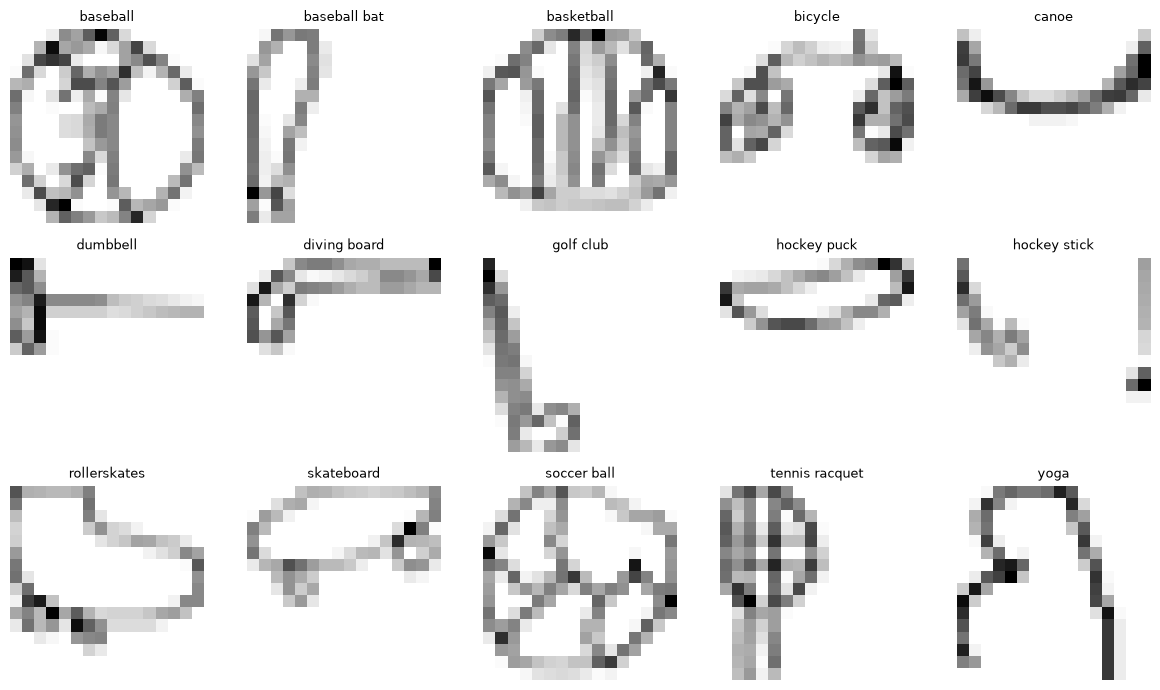

In [4]:
fig, axes = plt.subplots(3, 5, figsize=(12, 7))
for i, category in enumerate(CATEGORIES):
    idx = labels.index(category) 
    ax = axes[i // 5, i % 5]
    ax.imshow(images[idx], cmap='gray')
    ax.set_title(labels[idx], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()


In [5]:
label_map = {cat: i for i, cat in enumerate(CATEGORIES)}

X = np.array(images) / 255.0
y = np.array([label_map[l] for l in labels])

X_flat = X.reshape(X.shape[0], -1) 

X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (6000, 256), Test: (1500, 256)


In [6]:
results = {}

for k in [1, 3, 5, 7, 9]:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train, y_train)
    acc = knn.score(X_test, y_test)
    results[k] = acc
    print(f"k={k:2d}  ->  accuracy={acc:.4f}")

best_k = max(results, key=results.get)
print(f"\nBest k: {best_k} (accuracy={results[best_k]:.4f})")


k= 1  ->  accuracy=0.5707
k= 3  ->  accuracy=0.5573
k= 5  ->  accuracy=0.5567
k= 7  ->  accuracy=0.5467
k= 9  ->  accuracy=0.5467

Best k: 1 (accuracy=0.5707)


                precision    recall  f1-score   support

      baseball       0.45      0.59      0.51       100
  baseball bat       0.71      0.76      0.73       100
    basketball       0.37      0.22      0.28       100
       bicycle       0.80      0.74      0.77       100
         canoe       0.61      0.84      0.71       100
      dumbbell       0.76      0.63      0.69       100
  diving board       0.41      0.60      0.48       100
     golf club       0.40      0.50      0.44       100
   hockey puck       0.43      0.54      0.48       100
  hockey stick       0.46      0.61      0.52       100
  rollerskates       0.88      0.59      0.71       100
    skateboard       0.71      0.62      0.66       100
   soccer ball       0.61      0.23      0.33       100
tennis racquet       0.80      0.82      0.81       100
          yoga       0.46      0.27      0.34       100

      accuracy                           0.57      1500
     macro avg       0.59      0.57      0.56 

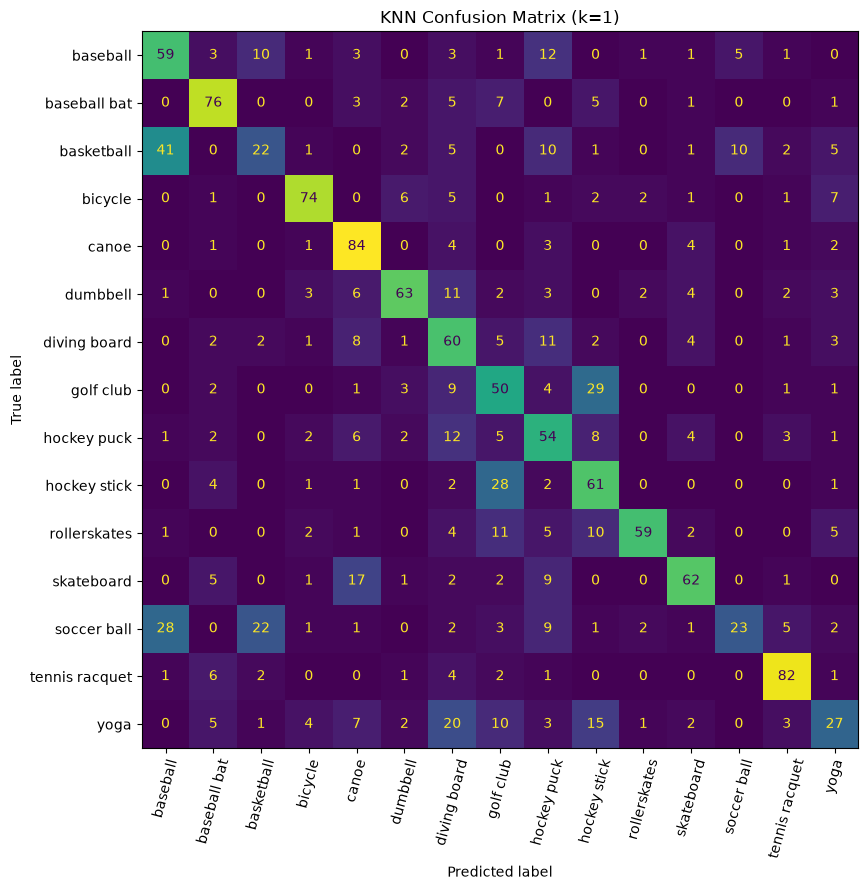

In [7]:
knn_final = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn_final.fit(X_train, y_train)
preds = knn_final.predict(X_test)

print(classification_report(y_test, preds, target_names=CATEGORIES, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 9))
ConfusionMatrixDisplay.from_predictions(
    y_test, preds, display_labels=CATEGORIES, xticks_rotation=75, ax=ax, colorbar=False
)
plt.title(f"KNN Confusion Matrix (k={best_k})")
plt.tight_layout()
plt.show()
